## Evaluation

In [150]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import confusion_matrix, classification_report, mean_absolute_error, mean_squared_error

In [152]:
# Predict using the validation generator
y_pred = model.predict(val_gen)
y_pred = y_pred.flatten()  # shape: (N,)

# Get true labels from the generator
y_true = val_gen.ages  # ground-truth ages

print("Predictions and ground truth loaded.")

1/1 ━━━━━━━━━━━━━━━━━━━━ 2s 2s/step
Predictions and ground truth loaded.


**Regression Metrics**


*   MAE
*   RMSE
*   Accuracy



In [163]:
from sklearn.metrics import mean_absolute_error, mean_squared_error
import numpy as np

mae = mean_absolute_error(y_true, y_pred)
mse = mean_squared_error(y_true, y_pred)
rmse = np.sqrt(mse)

accuracy_5 = np.mean(np.abs(y_pred - y_true) <= 5) * 100
accuracy_10 = np.mean(np.abs(y_pred - y_true) <= 10) * 100

print(f"MAE: {mae:.2f}")
print(f"RMSE: {rmse:.2f}")
print(f"Accuracy within ±5 years: {accuracy_5:.2f}%")
print(f"Accuracy within ±10 years: {accuracy_10:.2f}%")

MAE: 4.78
RMSE: 6.04
Accuracy within ±5 years: 61.54%
Accuracy within ±10 years: 96.15%


🔍 While the project requires evaluation metrics like precision, recall, and confusion matrix, it’s important to note that this task is inherently a regression problem, not a classification one.

To adapt to the requirement, I've grouped ages into bins (e.g., 20–30, 30–40) and evaluated classification metrics based on those bins. However, this does not reflect the full accuracy of the regression model, since it penalizes near-miss predictions across bin boundaries (e.g., predicting 39 instead of 40).



**Confusion Matrix with Precision & Recall**

Classification Report:

              precision    recall  f1-score   support

       20–30       1.00      0.33      0.50         3
       30–40       0.44      0.58      0.50        12
       40–50       0.44      0.36      0.40        11

    accuracy                           0.46        26
   macro avg       0.63      0.43      0.47        26
weighted avg       0.51      0.46      0.46        26



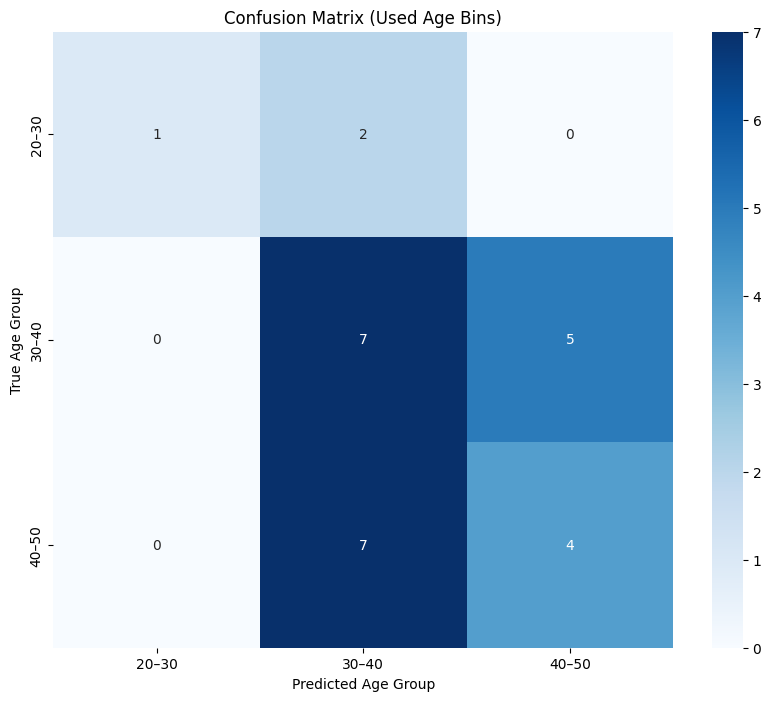

In [157]:
import numpy as np
from sklearn.metrics import classification_report, confusion_matrix
import matplotlib.pyplot as plt
import seaborn as sns

# Age bins
bins = [0, 10, 20, 30, 40, 50, 60, 70, 80, 90, 100]
labels = [f"{bins[i]}–{bins[i+1]}" for i in range(len(bins)-1)]

# Digitize ages into class indices
y_true_cls = np.digitize(y_true, bins)
y_pred_cls = np.digitize(y_pred, bins)

# 🔍 Get only used class indices
used_classes = sorted(np.unique(np.concatenate((y_true_cls, y_pred_cls))))
used_labels = [labels[i - 1] for i in used_classes]  # subtract 1 since bins start at 1

# ✅ Classification Report
print("Classification Report:\n")
print(classification_report(y_true_cls, y_pred_cls, labels=used_classes, target_names=used_labels, digits=2))

# ✅ Confusion Matrix
cm = confusion_matrix(y_true_cls, y_pred_cls, labels=used_classes)

plt.figure(figsize=(10, 8))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=used_labels, yticklabels=used_labels)
plt.xlabel("Predicted Age Group")
plt.ylabel("True Age Group")
plt.title("Confusion Matrix (Used Age Bins)")
plt.show()

**Some more evaluation metrics**

**1.) Scatter Plot**

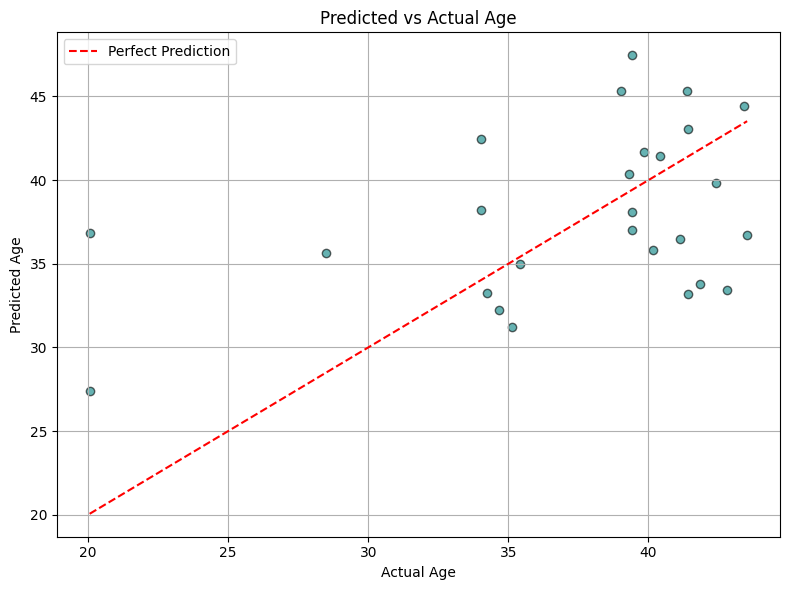

In [160]:
import matplotlib.pyplot as plt

plt.figure(figsize=(8, 6))
plt.scatter(y_true, y_pred, alpha=0.6, color='teal', edgecolor='k')
plt.plot([min(y_true), max(y_true)], [min(y_true), max(y_true)], 'r--', label='Perfect Prediction')
plt.xlabel('Actual Age')
plt.ylabel('Predicted Age')
plt.title('Predicted vs Actual Age')
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()

**2.)  Residual Histogram**

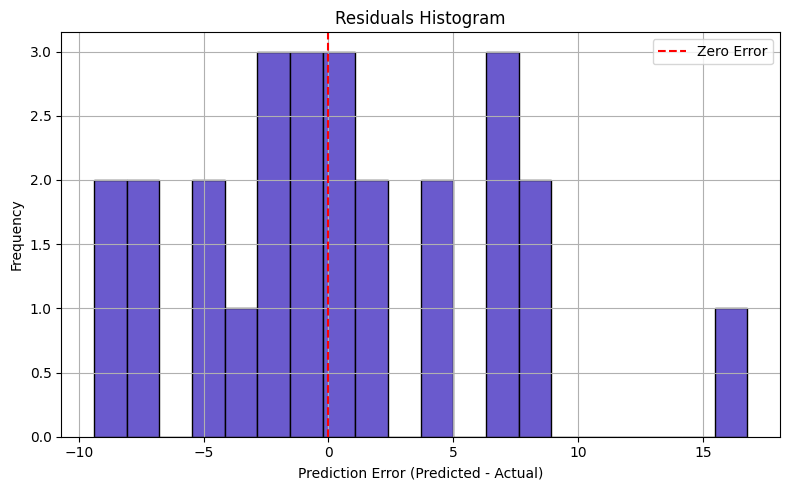

In [161]:
import numpy as np

residuals = np.array(y_pred) - np.array(y_true)

plt.figure(figsize=(8, 5))
plt.hist(residuals, bins=20, color='slateblue', edgecolor='black')
plt.axvline(0, color='red', linestyle='--', label='Zero Error')
plt.xlabel('Prediction Error (Predicted - Actual)')
plt.ylabel('Frequency')
plt.title('Residuals Histogram')
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()

**3.) Accuracy**

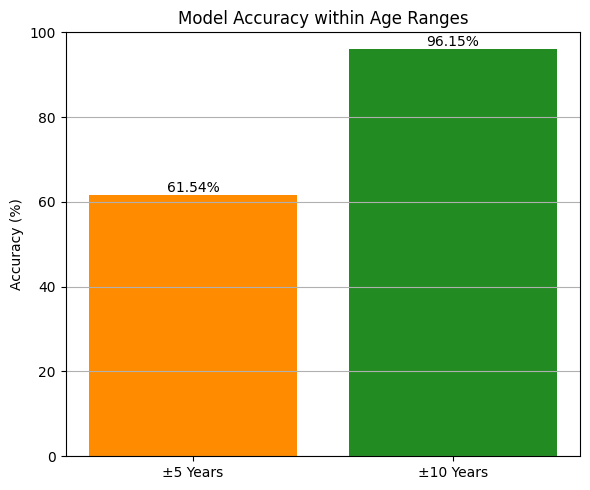

In [162]:
within_5 = np.abs(np.array(y_pred) - np.array(y_true)) <= 5
within_10 = np.abs(np.array(y_pred) - np.array(y_true)) <= 10

acc_5 = 100 * np.mean(within_5)
acc_10 = 100 * np.mean(within_10)

plt.figure(figsize=(6, 5))
bars = plt.bar(['±5 Years', '±10 Years'], [acc_5, acc_10], color=['darkorange', 'forestgreen'])
plt.ylim(0, 100)
plt.ylabel('Accuracy (%)')
plt.title('Model Accuracy within Age Ranges')
plt.bar_label(bars, fmt='%.2f%%')
plt.grid(axis='y')
plt.tight_layout()
plt.show()